
1. What Problem Do PINNs **Physics-Informed Nueral Networks** Solve?

    Engineering problems often involve differential equations:

    Heat transfer → heat equation

    Fluid dynamics → Navier–Stokes

    Electromagnetics → Maxwell equations

    Traditionally, you solve these using FEM, CFD, FDM, etc. But these can be:

    - Computationally expensive

    - Hard to adapt to complex geometries

    - Difficult when data is sparse or noisy

    - Slow when you need many repeated simulations (optimization, control, digital twins)

    PINNs provide an AI-based alternative that can solve or approximate PDE (Partial Differntial Equation) solutions by learning them.

2. What Is a PINN?

    A Physics-Informed Neural Network (PINN) learns a solution function $𝑢_{\theta}:(x,t)$ by fitting both the governing physics (PDE) and any available constraints/data. Instead of training only on labeled examples, we add a physics penalty so the network is discouraged from producing outputs that violate the differential equation.

    Here u is the predicted physical quantity (e.g. temperature, velocity, pressure, displacement), 

    x (spatial coordinates) which represents position in the physical domain,

    t (time) which represents the time variable in time-dependent PDEs (If the system is steady state, then there is no t), 

    and $\theta$ is all the weights and biases of the neural network (tunable network's parameters the network learns during training).

    The network output is $𝑢_{\theta}(x,t)$ which can be temperature, stress, velocity, concentration, etc.

   
    The loss function includes:

    $\mathcal{L}_{tot}$ =  $\mathcal{L}_{PDE}$ + $\mathcal{L}_{IC}$ + $\mathcal{L}_{BC}$ + $\mathcal{L}_{data}$ 

    where
    
    PDE residual loss ($\mathcal{L}_{PDE}$): enforces that the NN satisfies the differential equation inside the domain, 

    Initial condition loss ($\mathcal{L}_{IC}$): enforces the known system state at the start of time (for time-dependent problems),

    Boundary condition ($\mathcal{L}_{BC}$): enforces the constraints on the boundary of the spatial domain (edges/surfaces), for all relevant times. 

    Supervised data loss, optional ($\mathcal{L}_{data}$): used when you have measurements (sensor readings, experiments, or simulation samples). It makes the PINN match observed values at specific points.

**Advantages oF PINNs**:

- Combine information from both data and from physical models.
- Compared to traditional NNs,  $\mathcal{L}_{PDE}$   regularizes the model limiting overfitting and improving generalization.
- Compared to traiditional PDE solvers, PINNs are more scalable and can consume any kind of data.

**Steps for an example in Pytorch**:

- Define a neural network that can approximate the solution of a PDE.
- Apply automatic differentiation to compute derivatives with respect to input variables which represent physical quantities like space and time.
- Incorporate a physics-based loss term that penalizes the network for violating PDE constraints.

Our example here: A simple 1D PDE: Poisson with known solution

We’ll work on the interval $x \in [0,1]$ with:

$u ^{''} (x) = -\pi^2\sin(\pi x)$

A nice thing about this PDE: a known exact solution is

$u(x) = \sin(\pi x)$

So we can train our neural network $u_{\theta} (x)$ such that its second derivative matches $-\pi^2\sin(\pi x)$

We don’t even strictly need boundary conditions just to see non-zero loss and learning (though in a “real” PINN you’d add them too).

In [4]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Using device: cpu
Epoch 0, Loss: 49.012894
Epoch 500, Loss: 0.003018
Epoch 1000, Loss: 0.002501
Epoch 1500, Loss: 0.001784
Epoch 2000, Loss: 0.001165
Epoch 2500, Loss: 0.000756
Epoch 3000, Loss: 0.000427
Epoch 3500, Loss: 0.000224
Epoch 4000, Loss: 0.000145
Epoch 4500, Loss: 0.000123


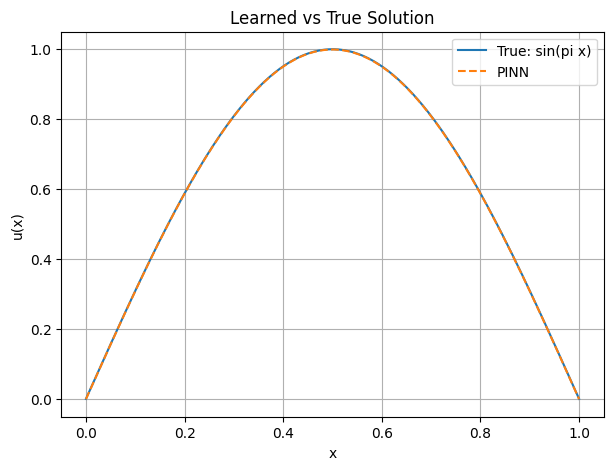

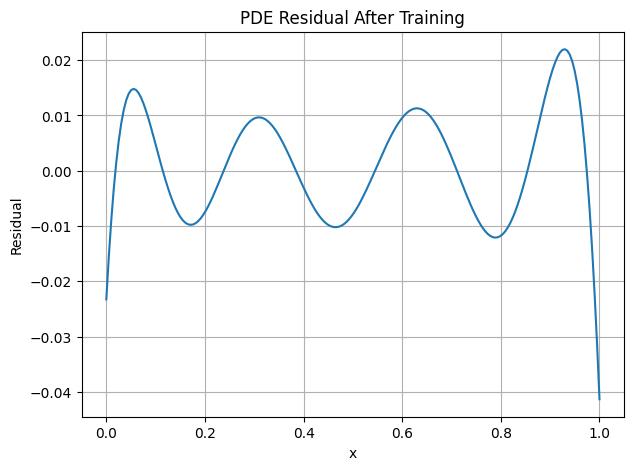

In [ ]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# # 1. Problem definition & constraints
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

L = 1.0
pi = math.pi

pi_t = torch.tensor(pi, dtype=torch.float32, device=device)
L_t  = torch.tensor(L,  dtype=torch.float32, device=device)

def rhs_pde(x):
    return - (pi_t**2) * torch.sin(pi_t * x)

# Analytic solution
def analytic_u(x):
    return torch.sin(pi_t * x)


# 2. PINN architecture
class SimpleNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

network = SimpleNN().to(device)


# 3. Loss functions
def physics_loss(model, x):
    x = x.clone().detach().requires_grad_(True)
    u = model(x)
    du = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    d2u = torch.autograd.grad(du.sum(), x, create_graph=True)[0]
    return torch.mean((d2u - rhs_pde(x))**2)

def boundary_loss(model):
    x0 = torch.tensor([[0.0]], device=device)
    x1 = torch.tensor([[1.0]], device=device)

    u0 = model(x0)   # should be 0
    u1 = model(x1)   # should be 0

    return (u0**2 + u1**2).mean()

def total_loss(model, x, w_bc=10.0):
    return physics_loss(model, x) + w_bc * boundary_loss(model)

# 4. Training data
N = 100
x_train = torch.linspace(0, L, N, device=device).view(-1, 1)

# 5. Training loop
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
epochs = 5000

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = total_loss(network, x_train, w_bc=10.0)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# 6. PLOT: learned vs analytic
x_test = torch.linspace(0, L, 200, device=device).view(-1, 1)
with torch.no_grad():
    u_pred = network(x_test).cpu().numpy()
u_true = analytic_u(x_test).cpu().numpy()

plt.figure(figsize=(7,5))
plt.plot(x_test.cpu(), u_true, label="True: sin(pi x)")
plt.plot(x_test.cpu(), u_pred, "--", label="PINN")
plt.xlabel("x"); plt.ylabel("u(x)")
plt.legend(); plt.grid(); plt.title("Learned vs True Solution")
plt.show()

# 7. PLOT: residual
x_res = x_test.clone().detach().requires_grad_(True)
u = network(x_res)
du = torch.autograd.grad(u.sum(), x_res, create_graph=True)[0]
d2u = torch.autograd.grad(du.sum(), x_res, create_graph=True)[0]
residual = (d2u - rhs_pde(x_res)).detach().cpu().numpy()

plt.figure(figsize=(7,5))
plt.plot(x_test.cpu(), residual)
plt.xlabel("x"); plt.ylabel("Residual")
plt.title("PDE Residual After Training")
plt.grid(); plt.show()
